# 이안류 YOLO 학습 데이터 만들기

루트의 `이안류/290.이안류 CCTV 데이터`를 읽어서 `이안류/YOLO` 아래에 YOLO 형식 데이터셋을 만듭니다.
카메라별로 묶은 뒤 촬영 시각순으로 정렬해서 `train/val/test`를 나눕니다.

In [1]:
from collections import defaultdict
from datetime import datetime
from pathlib import Path
import json
import shutil
import zipfile

cwd = Path.cwd()
ROOT = cwd if (cwd / "이안류").exists() else cwd.parent

DATA = ROOT / "이안류" / "290.이안류 CCTV 데이터"
YOLO = ROOT / "이안류" / "YOLO"

assert DATA.exists(), f"원본 데이터 폴더가 없습니다: {DATA}"

# 이전 변환 결과가 섞이지 않게 YOLO 이미지/라벨만 새로 만듭니다.
for name in ["images", "labels"]:
    shutil.rmtree(YOLO / name, ignore_errors=True)

for split in ["train", "val", "test"]:
    (YOLO / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO / "labels" / split).mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("YOLO:", YOLO)

ROOT: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision
DATA: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\이안류\290.이안류 CCTV 데이터
YOLO: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\이안류\YOLO


## 1. zip 이미지 풀기

원천데이터가 zip으로 들어있는 경우가 있어서, 같은 이름의 폴더에 압축을 풉니다. 이미 풀려 있으면 건너뜁니다.

In [2]:
for split_name in ["Training", "Validation"]:
    image_root = DATA / split_name / "01.원천데이터"
    zip_files = list(image_root.rglob("*.zip"))

    for zip_path in zip_files:
        out_dir = zip_path.with_suffix("")
        if out_dir.exists():
            continue

        out_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(out_dir)

    print(split_name, "zip files:", len(zip_files))

Training zip files: 17
Validation zip files: 17


## 2. 라벨과 이미지 모으기

파일명 끝의 `YYYYMMDD_HHMMSS`를 촬영 시각으로 사용합니다.

In [3]:
# 이미지 json 파일에서 시간 추출하기
def image_datetime(file_name):
    # 파일 이름의 확장자를 제외한 문자열 받기
    stem = Path(file_name).stem
    # 마지막 부분의 형태가 *_yyyymmdd_hhmmss.* 이기 때문에 아래와 같이 시간으로 만들어주는 함수 사용해주기
    ymd, hms = stem.split("_")[-2:]
    return datetime.strptime(ymd + hms, "%Y%m%d%H%M%S")


def collect_items():
    # 이미지 데이터와 items (values 묶음) 만들어주기
    # images에는 파일 이름(확장자 제외)를
    images = {}
    # items에는 실제로 데이터를 분할할 때
    items = []

    # 기본 aihub 데이터는 아래 두 폴더로 이루어져잇음
    # 양쪽 폴더를 구분하지 않고 하나의 변수에 저장해줍니다. (따로 나누었습니다.)
    for src_split in ["Training", "Validation"]:
        # 고정된 경로
        image_root = DATA / src_split / "01.원천데이터"
        label_root = DATA / src_split / "02.라벨링데이터"

        # 확장자를 제외한 이름에 대해서 이미지 path 자체를 저장해놓아 줍니다.
        # 이는 캐싱 성격을 이용하여 나중에 라벨만을 통해 이미지를 찾을 수 있게 하는 방식입니다.
        # 이걸 하지 않았어서 고생을 좀 했었습니다.
        images.update({p.name: p for p in image_root.rglob("*.jpg")})

        # 라벨 또한 동일하게 저장 + items 저장
        for json_path in label_root.rglob("*.json"):
            # json 텍스트를 읽어서 이를 통해 데이터들을 뽑아줍니다.
            obj = json.loads(json_path.read_text(encoding="utf-8"))
            image_name = obj["image_info"]["file_name"]
            # 필요한 데이터 넣기
            items.append({
                "json_path": json_path,
                "image_name": image_name,
                "image_path": images.get(image_name),
                "id_code": obj["image_info"]["ID_code"],
                "datetime": image_datetime(image_name),
                "obj": obj,
            })

    return items


# 데이터를 뽑아서 넣어줍니다. 이제 이 list를 순회하기만 하면 됩니다.
items = collect_items()
missing = [item["image_name"] for item in items if item["image_path"] is None]

print("labels:", len(items))
print("missing images:", len(missing))
print("missing sample:", missing[:10])

labels: 279151
missing images: 0
missing sample: []


## 3. 카메라별 시간순으로 나누기

각 카메라 안에서 과거 80%는 train, 다음 10%는 val, 마지막 10%는 test로 둡니다.
YOLO 학습은 train/val만 쓰고, test는 나중에 최종 확인용입니다.

In [4]:
# if groups.get(...) is None 같은걸 쓰지 않기 위해 사용
groups = defaultdict(list)
# 요소들을 모두 순회면서 image가 있을 때 id코드에 따라 카메라를 나누어주기.
# train, test, val을 모두 하나로 병합하여 사용해줍니다.
for item in items:
    if item["image_path"] is not None:
        # { 케메라 id: item } 형태로 만들어주기
        groups[item["id_code"]].append(item)

split_items = {"train": [], "val": [], "test": []}

# 각각 시계열로 나누어 활용할 수 있게 합니다.
for id_code, group in groups.items():
    group.sort(key=lambda x: x["datetime"])

    # 비율을 8:1:1 형태로 나누어줍니다.
    n = len(group)
    train_end = int(n * 0.8)
    val_end = int(n * 0.9)

    # 데이터를 그대로 추가해주어서 비율대로 넣어줍니다.
    split_items["train"].extend(group[:train_end])
    split_items["val"].extend(group[train_end:val_end])
    split_items["test"].extend(group[val_end:])

for split, rows in split_items.items():
    print(split, len(rows))

train 223316
val 27914
test 27921


## 4. JSON 라벨을 YOLO txt로 변환

이 데이터는 이안류 하나만 학습하므로 클래스 번호는 항상 `0`입니다.

In [5]:
# yolo 방식의 어노테이션 만드는 함수
def box_to_yolo_line(box, img_w, img_h):
    xs = [p[0] for p in box]
    ys = [p[1] for p in box]

    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)

    x = ((xmin + xmax) / 2) / img_w
    y = ((ymin + ymax) / 2) / img_h
    w = (xmax - xmin) / img_w
    h = (ymax - ymin) / img_h

    return f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}"


def write_yolo_item(item, split):
    obj = item["obj"]
    image_name = item["image_name"]
    img_w, img_h = map(int, obj["image_info"]["resolution"].split(","))
    lines = []

    # 이미 bbox에서 추출해놓은 어노테이션에서 yolo의 어노테이션 방식으로 만들어주기
    if obj["annotations"].get("class") == 1:
        for box in obj["annotations"].get("drawing", []):
            lines.append(box_to_yolo_line(box, img_w, img_h))

    # shutil을 이용해서 하나씩 데이터를 옮겨주기: 앞에서 뽑아놓은 image_path를 여기에서 사용해주기
    shutil.copy2(item["image_path"], YOLO / "images" / split / image_name)
    # YOLO 에 존재하는 label 위치에 YOLO 형식의 어노테이션을 만들어서 작성해주기
    (YOLO / "labels" / split / f"{Path(image_name).stem}.txt").write_text(
        "\n".join(lines),
        encoding="utf-8",
    )

In [6]:
# train, test, val 로 나누어서 돌려주기 (각각 데이터에는 list[item]이 들어있습니다.)
for split, rows in split_items.items():
    for item in rows:
        write_yolo_item(item, split)

# 개수 확인하기
for split in ["train", "val", "test"]:
    image_count = len(list((YOLO / "images" / split).glob("*.jpg")))
    label_count = len(list((YOLO / "labels" / split).glob("*.txt")))
    print(split, "images:", image_count, "labels:", label_count)

train images: 223316 labels: 223316
val images: 27914 labels: 27914
test images: 27921 labels: 27921


## 5. 변환 결과 확인

In [7]:
sample_label = next((YOLO / "labels" / "train").glob("*.txt"), None)
if sample_label:
    print("sample label:", sample_label.name)
    print(sample_label.read_text(encoding="utf-8")[:500])

sample label: DC_MUDCH_20190705_133730.txt



## 6. YOLO dataset yaml 만들기

In [8]:
yaml_path = YOLO / "rip_current.yaml"
yaml_path.write_text(
    f"""path: {YOLO.as_posix()}
train: images/train
val: images/val
test: images/test

names:
  0: rip_current
""",
    encoding="utf-8",
)

print(yaml_path)
print(yaml_path.read_text(encoding="utf-8"))

C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\이안류\YOLO\rip_current.yaml
path: C:/LANG_CHAIN_2026/2026-05-19_KDT_lang_chain/01_class/computer_vision/이안류/YOLO
train: images/train
val: images/val
test: images/test

names:
  0: rip_current



## 7. 학습

`yolo11s.pt`가 lessons 폴더에 있으면 그 파일을 쓰고, 없으면 Ultralytics가 자동으로 모델을 받습니다.
GPU가 안 잡히면 `device="cpu"`로 바꿔서 실행하세요.

In [9]:
from ultralytics import YOLO

weights = Path.cwd() / "yolo11s.pt"
model = YOLO(str(weights) if weights.exists() else "yolo11s.pt")

model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,
    project=str(YOLO / "runs"),
    name="rip_current_yolo11s",
    exist_ok=True,
    save_period=1,
)

New https://pypi.org/project/ultralytics/8.4.148 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.143  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti Laptop GPU, 12227MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\\YOLO\rip_current.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width

KeyboardInterrupt: 

In [11]:
save_dir = ROOT / "이안류" / "YOLO" / "runs" / "rip_current_yolo11s" / "weights"

save_dir.mkdir(parents=True, exist_ok=True)

model.save(save_dir / "interrupted_after_epoch1.pt")

print(save_dir / "interrupted_after_epoch1.pt")

C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\이안류\YOLO\runs\rip_current_yolo11s\weights\interrupted_after_epoch1.pt


In [12]:
saved = YOLO(str(save_dir / "interrupted_after_epoch1.pt"))
saved.val(data=str(yaml_path))

Ultralytics 8.4.143  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti Laptop GPU, 12227MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 12,867 gradients, 21.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 88.582.4 MB/s, size: 132.1 KB)
val: Scanning C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\이안류\YOLO\labels\val.cache... 27914 images, 1590 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 27914/27914  0.0s
val: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\\YOLO\images\val\HD_GLORY_20200724_143311.jpg: 1 duplicate labels removed
val: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\\YOLO\images\val\HD_PARA1_20200724_143332.jpg: 1 duplicate labels removed
val: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\\YOLO\images\val\HD_PARA1_20200724_144355.jpg: 1 duplicate labels removed
val: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\\YOLO\

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000228CFF557F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

## 8. 예측 테스트

In [ ]:
best = YOLO / "runs" / "rip_current_yolo11s" / "weights" / "best.pt"
model = YOLO(str(best if best.exists() else weights))

sample_image = next((YOLO / "images" / "test").glob("*.jpg"))
results = model.predict(str(sample_image), save=True, conf=0.25)
print("sample:", sample_image)
print(results[0].save_dir)


image 1/1 C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\\YOLO\images\train\HD_PARA1_20190822_091842.jpg: 384x640 2 rip_currents, 24.3ms
Speed: 827.4ms preprocess, 24.3ms inference, 16.2ms postprocess per image at shape (1, 3, 384, 640)


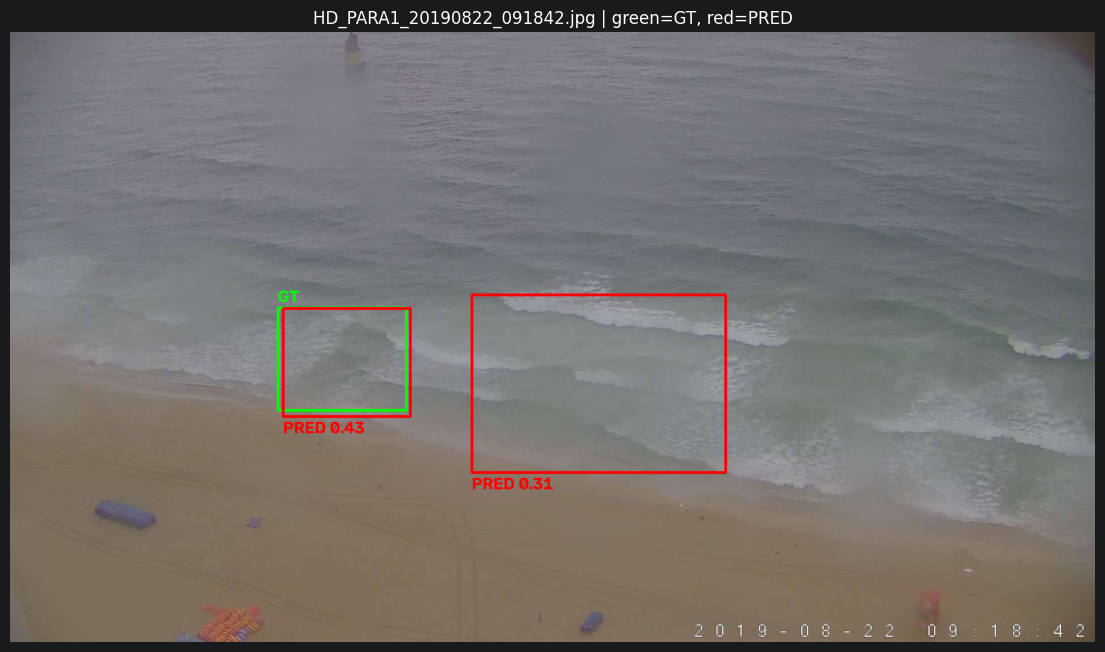

In [16]:
from pathlib import Path
import random
import cv2
import matplotlib.pyplot as plt

image_dir = Path(r"C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\이안류\YOLO\images\train")
label_dir = Path(r"C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\이안류\YOLO\labels\train")

image_path = random.choice(list(image_dir.glob("*.jpg")))
label_path = label_dir / f"{image_path.stem}.txt"

results = model.predict(
    source=str(image_path),
    conf=0.25,
    save=False,
)

img = cv2.imread(str(image_path))
h, w = img.shape[:2]

# 실제 정답 박스: 초록색
if label_path.exists():
    for line in label_path.read_text(encoding="utf-8").splitlines():
        cls, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw / 2) * w)
        y1 = int((y - bh / 2) * h)
        x2 = int((x + bw / 2) * w)
        y2 = int((y + bh / 2) * h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(
            img,
            "GT",
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2,
        )

# 예측 박스: 빨간색
for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = float(box.conf[0])

    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 3)
    cv2.putText(
        img,
        f"PRED {conf:.2f}",
        (x1, min(y2 + 30, h - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        2,
    )

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"{image_path.name} | green=GT, red=PRED")
plt.axis("off")
plt.show()